
---
title: Transmission Dither Locking, Pound-Drever-Hall Michelson, and Fabry-Perot Michelson  - Homework 04
date: 2025-04-06
authors:
  - name: Professor Craig Cahillane
    orcid: 0000-0002-3888-314X
    affiliations:
      - Syracuse University
numbering:
  heading_1: true
  heading_2: true
  heading_3: true
---

In [1]:
%matplotlib widget
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt
from ipywidgets import *
from sympy import *
from IPython.display import Latex



fontsize = 14
mpl.rcParams.update(
    {
        "text.usetex": False,
        "figure.figsize": (9, 6),
        # "figure.autolayout": True,
        # "font.family": "serif",
        # "font.serif": "georgia",
        # 'mathtext.fontset': 'cm',
        "lines.linewidth": 1.5,
        "font.size": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fancybox": True,
        "legend.fontsize": fontsize,
        "legend.framealpha": 0.7,
        "legend.handletextpad": 0.5,
        "legend.labelspacing": 0.2,
        "legend.loc": "best",
        "axes.edgecolor": "#b0b0b0",
        "grid.color": "#707070",  # grid color"
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "savefig.dpi": 80,
        "pdf.compression": 9,
    }
)

This is the fourth homework assignment for *Lasers and Optomechanics* at Syracuse University.\
**It is due Monday, April 6th, 2026 by 5 pm**

**<span style="color:#ff5555;">You will need to complete the questions in this jupyter notebook and submit it via `gitlab`</span>**


# Transmitted Field Dither Locking

In class, we investigated dither locking using the reflected field $E_\mathrm{refl}$ from a Fabry-Perot cavity.

In this problem, investigate whether it is possible to use $E_\mathrm{trans}$ to hold lock.


## Plot of Fabry-Perot $E_\mathrm{trans}$ versus $E_\mathrm{trans}$

Plot both $E_\mathrm{refl}$ and $E_\mathrm{trans}$ over a span of $\phi \in \left[ -\dfrac{\pi}{2},\dfrac{3\pi}{2} \right]$

Do you notice anything different about the resonance points?


## Total $E_\mathrm{trans}$ with end-mirror moduation 

If we apply an end-mirror modulation $\Delta x \cos(\omega t)$ to our Fabry-Perot cavity, 
what is the total $E_\mathrm{trans}(t)$ field?


## Calculate the total transmitted power $P_\mathrm{trans}(t)$

Calculate $P_\mathrm{trans}(t) = |E_\mathrm{trans}(t)|^2$

You may set $\Delta x^2 = 0$ for simplicity in the calculations.  
You should end up with only DC and 1$\omega$ terms.

You may leave this power term in a general form if you wish, 
but you must be clear what each of the contributing fields are.

## Calculate the transmitted power demodulated at $\omega$ 
Calculate the demodulated term $P_\mathrm{trans}(\omega) = P^I_\mathrm{trans}(\omega) + i P^Q_\mathrm{trans}(\omega)$.
This should be directly proportional to $\Delta x$.

## Plot the length to transmitted power function phase sweep
Plot the real and imaginary parts of $\dfrac{P_\mathrm{trans}(\omega)}{\Delta x}$ over $\phi \in \left[ -\dfrac{\pi}{2},\dfrac{3\pi}{2} \right]$

Choosing some low to moderate finesse cavity parameters, 
plot your derived function $\dfrac{P_\mathrm{trans}}{\Delta x}(\omega)$ as a function of carrier phase $\phi$.

Let the cavity parameters be
$$L = 1~\mathrm{m}\\ P_\mathrm{in} = 1~\mathrm{W}\\ T_1 = 0.3\\ T_2 = 0.3\\ \lambda = 1064~\mathrm{nm}\\ \omega = 2 \pi (100~\mathrm{Hz})$$

## Plot the length to transmitted power transfer function

Plot your transfer function magnitude and phase $\dfrac{P_\mathrm{trans}}{\Delta x}(\omega)$ as a function of frequency $f = \omega / (2\pi)$.

Use the same cavity parameters as above, but allow $f \in [3 \times 10^3, 3 \times 10^8]~\mathrm{Hz}$, while setting $\phi = 1^{\circ}$.

In [2]:
E_0 =10

t1 =0.1
t2 = 0.05


def Fab_refl (phi, t_1,t_2):
    r_1 = np.sqrt(1-t_1**2)
    r_2 = np.sqrt(1-t_2**2)
    numerator =r_1+r_2*np.exp(-2j*phi)
    denominator = 1- r_1*r_2*np.exp(-2j*phi)
    return(numerator/denominator)
    
def Fab_trans (phi, t_1,t_2):
    r_1 = np.sqrt(1-t_1**2)
    r_2 = np.sqrt(1-t_2**2)
    numerator =t_1*t_2*np.exp(-1j*phi)
    denominator = 1- r_1*r_2*np.exp(-2j*phi)
    return(numerator/denominator)

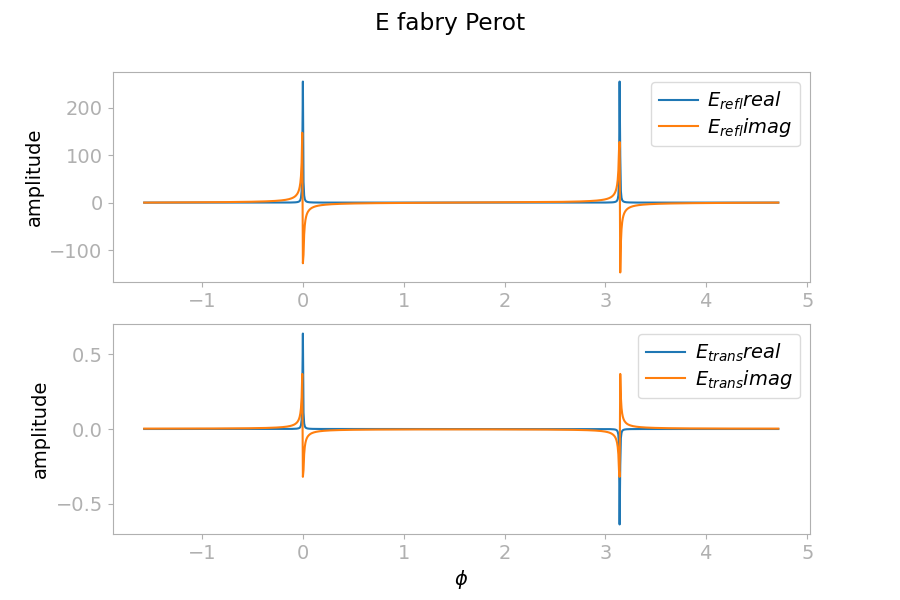

In [3]:

phi_range = np.linspace(-np.pi/2, 3*np.pi/2,1000)
fig,axes=plt.subplots(2,1)
trans_ys = np.real(Fab_trans(phi_range,t1,t2))
refl_ys= np.real(Fab_refl(phi_range,t1,t2))

plt.suptitle('E fabry Perot')
axes[0].plot(phi_range,refl_ys,label = r'$E_{refl} real$')
axes[0].plot(phi_range,np.imag(Fab_refl(phi_range,t1,t2)),label = r'$E_{refl} imag$')
axes[1].plot(phi_range,trans_ys,label = r'$E_{trans} real$')
axes[1].plot(phi_range,np.imag(Fab_trans(phi_range,t1,t2)),label = r'$E_{trans} imag$')
axes[0].set_ylabel('amplitude')
axes[1].set_ylabel('amplitude')
axes[1].set_xlabel(r'$\phi$')

axes[0].legend()
axes[1].legend()
plt.show()


In [7]:
t1 = symbols('t_1',real=True)
t2 = symbols('t_2',real=True)
r1 = symbols('r_1',real=True)
r2 = symbols('r_2',real=True)
E0 = symbols('E_0',real=True)
k = symbols('k',real=True)
phase1 = symbols('A_1',real=True)
phase2 = symbols('A_2',real=True)
eta= symbols('eta',real=True)

phi = symbols('phi',real=True)
omega = symbols('omega',real=True)
omega0 = symbols('omega_0',real=True)
time =symbols('t',real=True)

delt=symbols('Delta_x ',real=True)
#x = symbols('x',real=True)



no_mod_mat =Matrix([[1,0,0,0,0],
                     [-t1,1,r1*exp(-I*phi),0,0],
                     [0,r2*exp(-I*phi),1,0,0],
                     [-r1,0,-t1*exp(-I*phi),1,0],
                     [0,-t2*exp(-I*phi),0,0,1]
                    ])
modulation =(1+(delt/2)*exp(I*omega*time)*exp(-I*eta)+(delt/2)*exp(-I*omega*time)*exp(I*eta))

mod_mat =Matrix([[1,0,0,0,0],
                     [-t1,1,r1*exp(I*phi),0,0],
                     [0,r2*exp(I*phi)*modulation,1,0,0],
                     [-r1,0,-t1*exp(I*phi),1,0],
                     [0,-t2*exp(I*phi),0,0,1]
                    ])




#original_transfer = no_mod_mat.inv()
#mod_transfer_matrix = mod_matrix.inv()

test = '$$'+latex(no_mod_mat.inv())+'$$'


#Latex(inp)
Latex(test)




<IPython.core.display.Latex object>

# 
Question 1 part 2

we can write $E_{trans}(\phi)$ as

\begin{align}

E_{trans,total}(\phi) = (E_{trans,carrier}+E_{trans,upper}+E_{trans,lower})e^{i\omega t}

\end{align}

where 

\begin{align}

E_{trans,carrier} = \frac{t_1 t_2 e^{-i\phi}}{1-r_1 r_2 e^{-2i\phi}}
\end{align}
\begin{align}
E_{trans,upper} = \frac{t_1^2 t_2 ik \Delta x e^{-i(2\phi+\eta-\omega t)}}{(1-r_1 r_2 e^{-2i\phi})(1-r_1 r_2 e^{-2i(\phi+\eta)})}


\end{align}

and
\begin{align}
E_{trans,lower} = \frac{t_1^2 t_2 ik \Delta x e^{-i(2\phi+\eta+\omega t)}}{(1-r_1 r_2 e^{-2i\phi})(1-r_1 r_2 e^{-2i(\phi+\eta)})}
\end{align}

In [8]:
denom = (1-r1*r2*exp(-2*I*phi))
E0= symbols('E_0',real=True)
e_in=E0*exp(I*omega0*time)
e_carrier= t1*t2*exp(-I*phi)/(denom)

e_upper = (t1**2*t2*I*k*delt*exp(-I*(2*phi+eta-time*omega)))/(denom*(1-r1*r2*exp(-2*I*(phi+eta))))


e_lower = (t1**2*t2*I*k*delt*exp(-I*(2*phi-eta+time*omega)))/(denom*(1-r1*r2*exp(-2*I*(phi-eta))))

E_trans=e_in*(e_carrier+e_upper+e_lower)

output = '$$E_{trans}(t) = '+latex(E_trans)+'$$'
Latex(output)

<IPython.core.display.Latex object>

In [9]:
power_trans = (E_trans*conjugate(E_trans)).expand().subs(delt**2,0)
test = E_trans.conjugate()
testing= '$$' +latex(test)+'$$'
output = '$$P_{trans}(t) = '+latex(power_trans)+'$$'
Latex(output)

<IPython.core.display.Latex object>

Simplified using Mathematica

\begin{align}

P_{trans}(t) = \frac{E_0^2 t_1^2 t_2^2}{1-r_1^2 r_2^2 -2 r_1 r_2 cos(2\phi)} +\frac{4 E_0^2 k t_1^3 t_2^2 \Delta x cos(t \omega) sin(\eta+\phi)(1+r_1 r_2)}{(1+r_1^2 r_2^2 -2 r_1 r_2 cos(2\phi))(1+r_1^2 r_2^2 - 2 r_1 r_2 cos(2(\eta+\phi))}
\end{align}

# Demodulation

In [10]:
integrand=symbols('kappa',real=True)
pi=symbols('pi',real=True)
denom = 1+r1**2*r2**2 - 2*r1*r2*cos(2*phi)
p_simp = (E0**2 *t1**2*t2**2)/(denom) + (4*E0**2 * k*delt*t1**3 *t2**2 *sin(eta+phi)*cos(omega*time)*(1+r1*r2))/(denom*(1+r1**2 *r2**2 - r1*r2*cos(2*(eta+phi))))

p_integration = p_simp.subs(time*omega,integrand)
p_dc = integrate(p_integration , (integrand,0,2*pi))*1/(2*pi)
#p_Q = integrate(p_integration*sin(integrand) , (integrand,0,2*pi))*1/(2*pi)
#p_I = integrate(p_integration*cos(integrand) , (integrand,0,2*pi))*1/(2*pi)


test_out = '$$'+latex(p_simp.subs([(sin(2*pi),0),(cos(2*pi),1)]))+'$$'
#power_i ='$$P_{I} = '+latex(p_I.subs([(sin(2*pi),0),(cos(2*pi),1)]))+'$$'
#power_q = '$$P_{Q} = '+latex(p_Q.subs([(sin(2*pi),0),(cos(2*pi),1)]))+'$$'
power_dc = '$$P_{DC} = '+latex(p_dc.subs([(sin(2*pi),0),(cos(2*pi),1)]))+'$$'
Latex(power_dc)

<IPython.core.display.Latex object>

$P_{i}$ found using mathematica

\begin{align}
\frac{2 E_0^2 k (1+r_1 r_2) t_1^3 t_2^2 \Delta x  sin(\eta+\phi)}{(1+r_1^2 r_2^2 -2 r_1 r_2 cos(2\phi))(1+r_1^2 r_2^2 - 2r_1 r_2 cos(2(\eta+\phi)))}
\end{align}

and $P_{Q}$ is 0

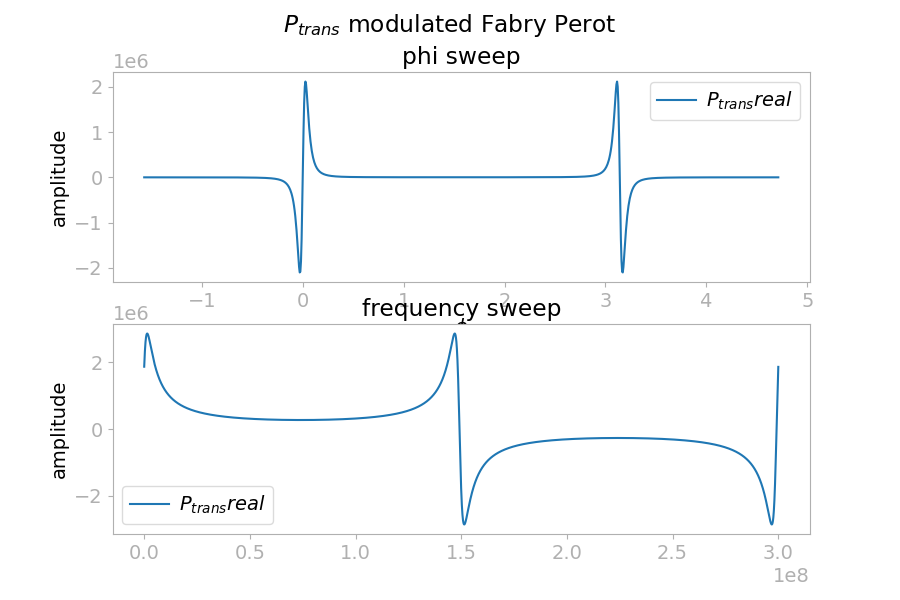

In [11]:
fig,axes=plt.subplots(2,1)
c=3*10**8
def power_trans_func(E,phi,t1,t2,l,om,lam):
    r1=np.sqrt(1-t1**2)
    r2 = np.sqrt(1-t2**2)
    eta = om*l/c
    first_term = (E**2*t1**2*t2**2)/(r1**2*r2**2 - 2*r1*r2*np.cos(2*phi)+1)
    second_term_num = (2*E**2 *(1/lam))*(1+r1*r2)*t1**3*t2**2*np.sin(phi+eta)
   
    second_term_denom = ((1+r1**2*r2**2 - 2*r1*r2*np.cos(2*phi))*(1+r1**2*r2**2 -2*r1*r2*np.cos(2*(phi+eta))))
    
    power = (first_term+(second_term_num/second_term_denom))
    return(power)

pin = 1 #watt
L = 1 #meter
lamb = 1024*(10**-9) # meters
t_1 =0.3
t_2 = 0.3
omega = 2*np.pi*100 # hertz
phi_lock = (1/360)*2*np.pi

freq_sweep = np.linspace(3*10**3, 3*10**8,1000000)
omega_sweep  = freq_sweep*2*np.pi
ein = np.sqrt(pin)

phi_range = np.linspace(-np.pi/2, 3*np.pi/2,1000)


plt.suptitle('$P_{trans}$ modulated Fabry Perot')
axes[0].set_title('phi sweep')
axes[0].plot(phi_range,np.real(power_trans_func(ein,phi_range,t_1,t_2,L,omega,lamb)),label = r'$P_{trans} real$')


axes[0].set_ylabel('amplitude')
axes[1].set_ylabel('amplitude')
axes[0].set_xlabel(r'$\phi$')

axes[0].legend()
axes[1].set_title('frequency sweep')

axes[1].plot(freq_sweep,np.real(power_trans_func(ein,phi_lock,t_1,t_2,L,omega_sweep,lamb)),label = r'$P_{trans} real$')

axes[1].legend()
plt.show()


# Pound-Drever-Hall Michelson

In-class we went over the Pound-Drever-Hall (PDH) Fabry-Perot interferometer.

Now we'll try to apply the same technique lock a Michelson interferometer to it's carrier dark fringe.

Below is a diagram of a Michelson with carrier at $\omega_0$, 
and two RF phase sidebands created by an electro-optic modulator (EOM)
oscillating at $\Omega$ to create two frequencies $\omega_0 \pm \Omega$.\
Our goal is to calculate the PDH error signal $\epsilon_\mathrm{PDH}$ as a function of the carrier phase offset $\phi_d$ and RF sideband frequency $\Omega$.

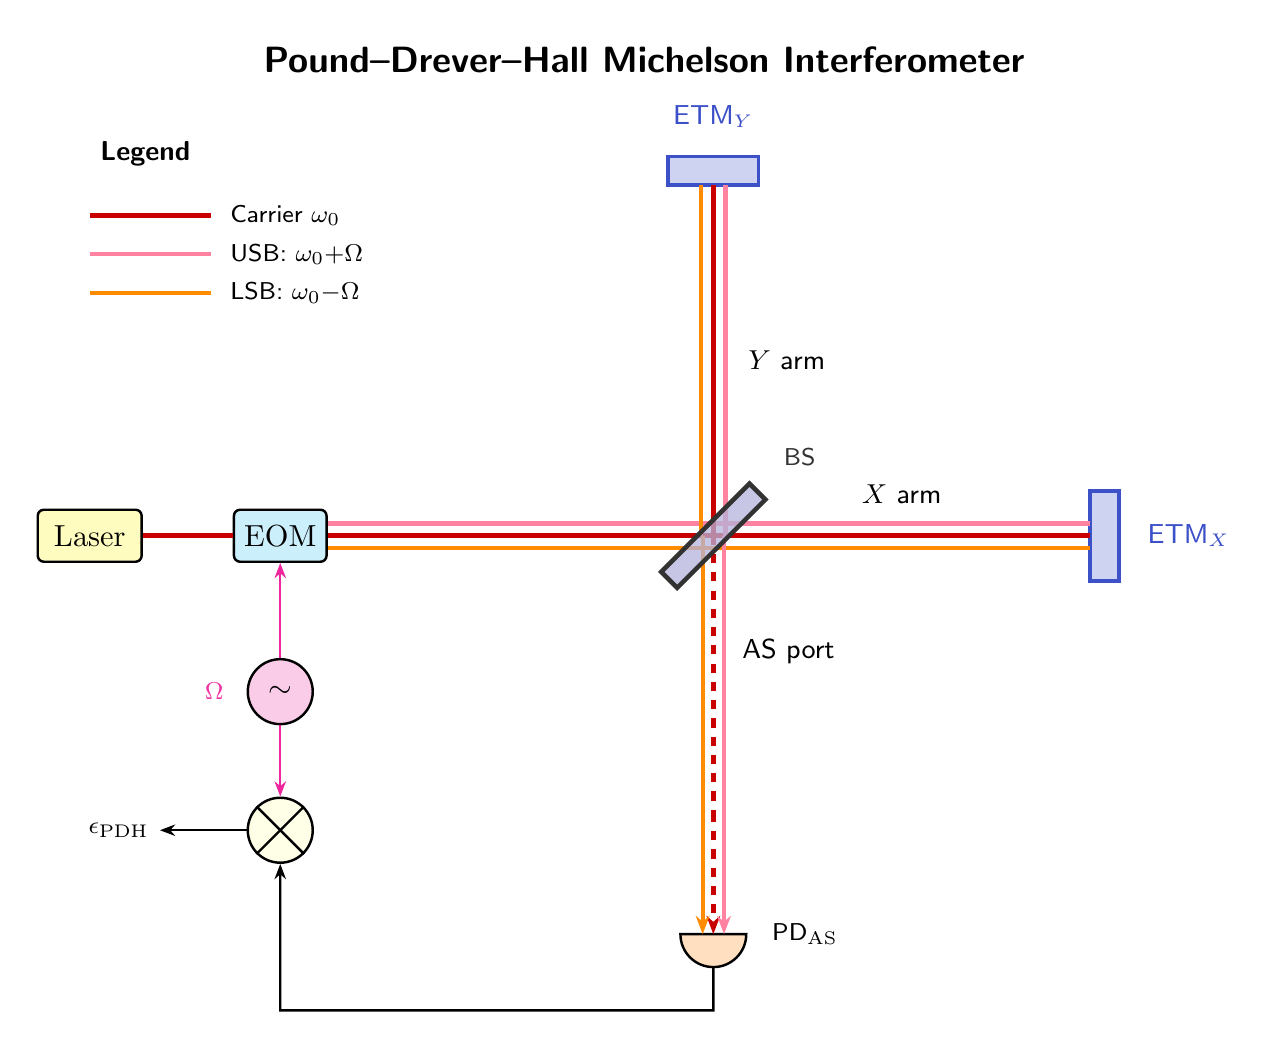

## Calculate the total dark field $E_{as}(t)$.

Calculate the full field expression $E_{as}(t)$ at the dark port of the interferometer.

There should be three contributions, one from carrier and two from the RF phase sidebands injected alongside the carrier.

Let the modulation depth of the RF sideband be $\Gamma$.\
Let the carrier differential phase be $\phi_d = \omega_0 (L_x - L_y) / c$,\
and the RF phase differential phase be $\varphi_d = \Omega (L_x - L_y) / c$.\

What happens to our phases and $E_{as}(t)$ if $L_x = L_y$ exactly?

*Hint: The RF sidebands will experience a phase shift of $\phi_d \pm \varphi_d$ as it transmitted through the interferometer*

## Calculate the total dark power $P_{as}(t)$.

Calculate $P_{as}(t) = |E_{as}(t)|^2$.

Assume that the second order modulation terms $\Gamma^2 = 0$, for simplicity.

## Calculate the dark power demodulated at $\Omega$ 

Calculate and plot the phase sweep of $\dfrac{P_{as}}{\Gamma}(\phi_d, \varphi_d)$ for $\phi_d \in [-5\pi, 5\pi]$.
for some assumed cavity parameters:

$$L_x = 5~\mathrm{m}\\
L_y = 5~\mathrm{m}\\
\Omega = 2 \pi (10~\mathrm{MHz})\\
r_\mathrm{bs} = t_\mathrm{bs} = \dfrac{1}{\sqrt{2}}\\
r_x = r_y = 1
$$

What do you notice about this signal $\dfrac{P_{as}}{\Gamma}(\phi_d, \varphi_d)$ as we increase the offset $\phi_d$?


due to the modulator

$E_{in}(t) = e^{-i\omega_0 t}(1+\frac{i\Gamma}{2} E^{-i\Omega t}+\frac{i\Gamma}{2} E^{i\Omega t})$

let 

$\phi_x = \frac{\omega_0 L_x}{c}$, 
$\phi_y = \frac{\omega_0 L_y}{c}$, 
$\phi_{x,usb} = \frac{(\omega_0+\Omega) L_x}{c}$, 
$\phi_{x,lsb} = \frac{(\omega_0-\Omega) L_x}{c}$, 
$\phi_{y,usb} = \frac{(\omega_0+\Omega) L_y}{c}$, 
$\phi_{y,lsb} = \frac{(\omega_0-\Omega) L_y}{c}$

I am also going to define

$\phi_c = \frac{\omega_0}{c}(L_x+L_y)$

$\varphi_c = \frac{\Omega}{c}(L_x+L_y)$

\begin{align}
Refl(\phi_x,\phi_y) = r_\mathrm{bs} t_{bs} r_y e^{-i 2 \phi_y} - t_\mathrm{bs} r_{bs} r_x e^{-i 2 \phi_x}\\

E_{as} = E_{in}(Refl(\phi_x,\phi_y)+i \frac{\Gamma}{2} Refl(\phi_{x,usb},\phi_{y,usb}) e^{i \Omega t} +i \frac{\Gamma}{2} Refl(\phi_{x,lsb},\phi_{y,lsb}) e^{-i \Omega t})\\

E_{as}(t) = E_{in}((r_\mathrm{bs} t_{bs} r_y e^{-i 2 \frac{\omega_0 L_x}{c}} - t_\mathrm{bs} r_{bs} r_x e^{-i 2 \frac{\omega_0 L_y}{c}})+i \frac{\Gamma}{2}(r_\mathrm{bs} t_{bs} r_y e^{-i 2 \phi_{y,usb}} - t_\mathrm{bs} r_{bs} r_x e^{-i 2 \phi_{x,usb}}) e^{i \Omega t} +i \frac{\Gamma}{2} (r_\mathrm{bs} t_{bs} r_y e^{-i 2 \phi_{y,lsb}} - t_\mathrm{bs} r_{bs} r_x e^{-i 2 \phi_{x,lsb}}) e^{-i \Omega t})\\

E_{as}(t) = E_0 e^{i\omega_0 t}((r_\mathrm{bs} t_{bs} r_y e^{-i 2 \phi_y} - t_\mathrm{bs} r_{bs} r_x e^{-i 2 \phi_x})+i \frac{\Gamma}{2}(r_\mathrm{bs} t_{bs} r_y e^{-i 2 \frac{(\omega_0+\Omega) L_y}{c}} - t_\mathrm{bs} r_{bs} r_x e^{-i 2 \frac{(\omega_0+\Omega) L_x}{c}}) e^{i \Omega t} +i \frac{\Gamma}{2} (r_\mathrm{bs} t_{bs} r_y e^{-i 2 \frac{(\omega_0-\Omega) L_y}{c}} - t_\mathrm{bs} r_{bs} r_x e^{-i 2 \frac{(\omega_0-\Omega) L_x}{c}}) e^{-i \Omega t})\\

\end{align}

Allowing $L_x =L_y$, subing in $\phi_d$ and $\varphi_d$ and simplifying using mathematica leads to 

$E_{as}(t) = -i e^{\frac{-i (-2*L_y+ct) \Phi_d \Omega}{c \varphi_d}} E_0 r_{bs} t_{bs}(r_x-r_y) (-i+\Gamma cos(\frac{2 L_Y \Omega}{c}-t \Omega))$

which would be 0 under the usual assumption that $r_x =r_y$

Computed using mathematica

\begin{align}
P_{asym}(t) = E_0^2 r_{bs}^2  t_{bs}^2 (r_x^2 + r_y^2 -2 r_x r_y cos(2 \phi_d)+ 2 r_y \Gamma (-r_y cos(\phi_c - \varphi_d -t \Omega) sin(\phi_c - \varphi_c) + r_x cos(\phi_c +2 \phi_d -t\Omega) sin(\phi_c - \varphi_c -\varphi_d) +r_x cos(2 \phi_d -\varphi_c + t\Omega)sin(\varphi_d)) 
\end{align}

In [36]:
Gamma = symbols('Gamma',real=True)
psid = symbols('varphi_d',real=True)
psic = symbols('varphi_d',real=True)
Lx = symbols('L_x',real=True)
Ly = symbols('L_y',real=True)
lx = symbols('l_x',real=True)
ly = symbols('l_y',real=True)
rbs = symbols('r_bs',real=True)
tbs = symbols('t_bs',real=True)
tx = symbols('t_x',real=True)
ty = symbols('t_y',real=True)
rx = symbols('r_x',real=True)
ry = symbols('r_y',real=True)
rxe = symbols('r_xe',real=True)
rye = symbols('r_ye',real=True)
Phix = symbols('Phi_x',real=True)
Phiy = symbols('Phi_y',real=True)
Phid = symbols('Phi_d',real=True)
phid = symbols('Phi_d',real=True)
Phic = symbols('Phi_c',real=True)
Omega =symbols('Omega',real=True)
c=symbols('c',real=True)


term1 = E0**2*rbs**2*tbs**2*rx*ry*Gamma*sin(Omega*(2*Lx*phid-2*Ly*phid-2*Lx*psid+c*time*psid)/(c*psid))
term2 = E0**2*rbs**2*tbs**2*rx*ry*Gamma*sin(Omega*(-2*Lx*phid+2*Ly*phid-2*Lx*psid+c*time*psid)/(c*psid))
term3 = E0**2*rbs**2*tbs**2*rx*ry*Gamma*sin(Omega*(-2*Lx*(phid+psid)+2*Ly*phid+c*time*psid)/(c*psid))
term4 = E0**2*rbs**2*tbs**2*rx*ry*Gamma*sin(Omega*(-2*Ly*(phid+psid)+2*Lx*phid+c*time*psid)/(c*psid))

power_as = E0**2 *rbs**2*rx**2*tbs**2+ E0**2 *rbs**2*ry**2*tbs**2-2*E0**2 *rbs**2*rx**2*tbs**2*ry*cos((2*(Lx-Ly)*phid*Omega)/(c*psid))-term1+term2+term3+term4


p_as ='$$P_{as} = '+latex(power_as)+'$$'
Latex(p_as)

<IPython.core.display.Latex object>

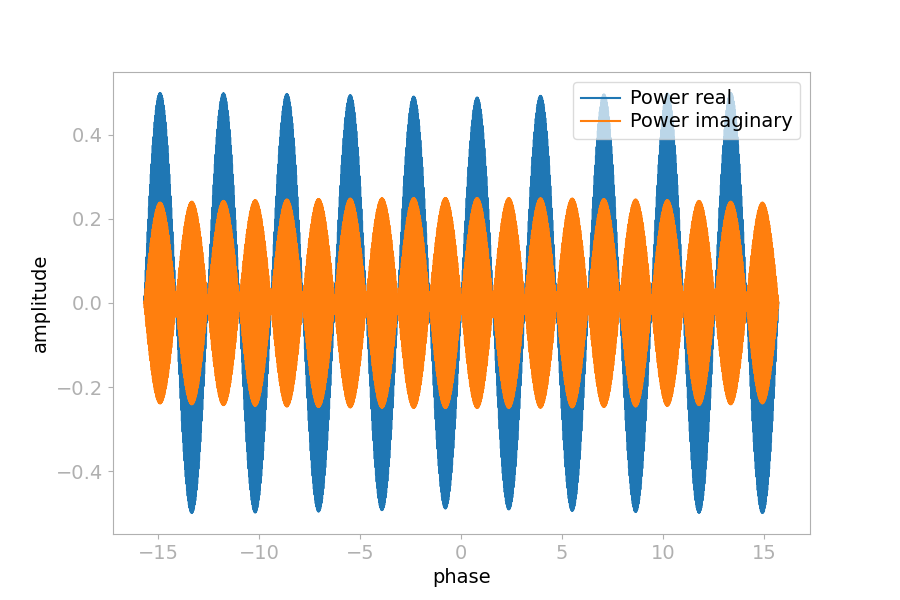

<IPython.core.display.Latex object>

In [42]:



P_asI = cos(phid)*sin(phid)*sin(psic)*sin(psid)
P_asQ = cos(phid)*sin(phid)*cos(psic)*sin(psid)
P_tot = (P_asI+I*P_asQ).subs([(psid,100*phid),(psic,(10000/(3*(10**8)))*10)])

lphi_range = np.linspace(-5*np.pi,5*np.pi,10000)


power_func = lambdify(phid, P_tot, 'numpy')
fig2,axis = plt.subplots(1)

axis.plot(lphi_range,np.real(power_func(lphi_range)),label = 'Power real')
axis.plot(lphi_range,np.imag(power_func(lphi_range)),label = 'Power imaginary')


axis.set_ylabel('amplitude')
axis.set_xlabel('phase')
axis.legend()

plt.show()


power_total ='$$P_{tot} = '+latex(P_tot)+'$$'
Latex(power_total)  


# Note on the plot

I derived the power using a different method and I highly doubt this is correct since it seems like $\phi_d$ will alwys be zero given the condition that $L_x =L_y$

# Fabry-Perot Michelson Interferometer (FPMI)

We investigated *compound interferometers* in class when we studied the coupled-cavity.\
Here we combine our Michelson interferometer with Fabry-Perot interferometers forming the arms,
forming the Fabry-Perot Michelson Interferometer (FPMI) in a configuration similar to LIGO.

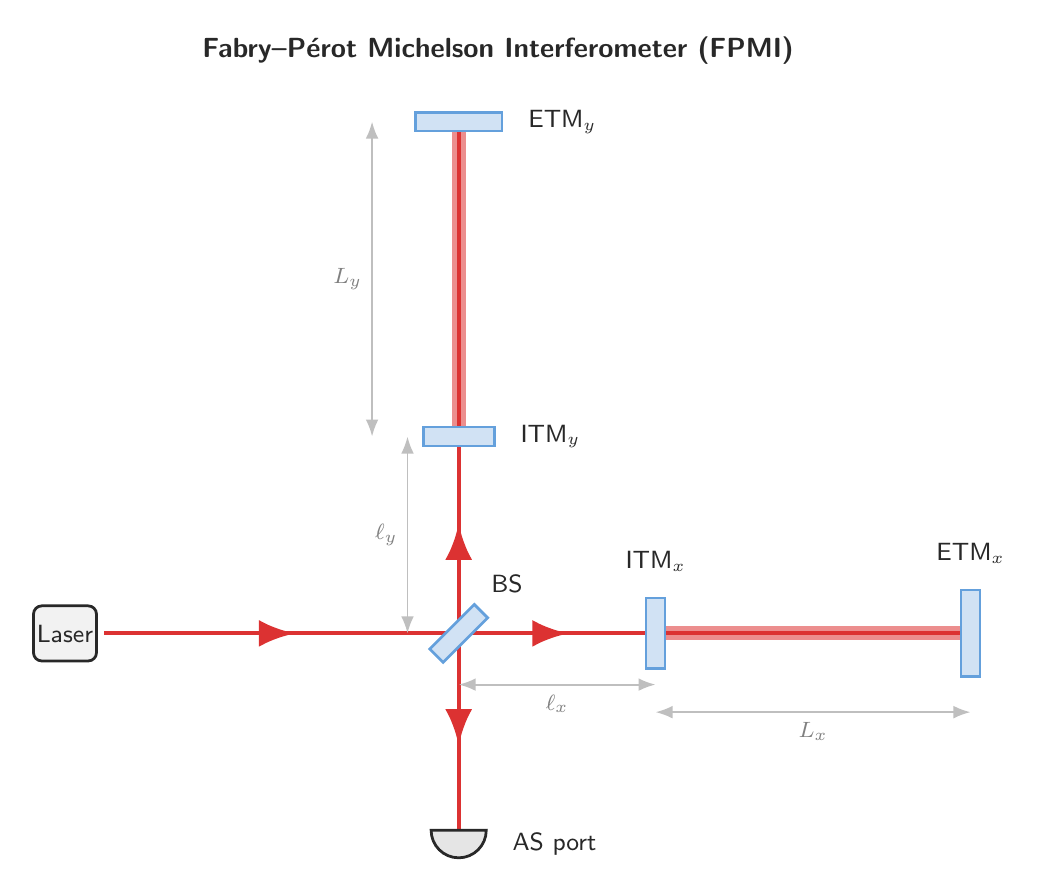

## Adjacency Matrix

Form an adjacency matrix for the FPMI interferometer.

I recommend using $\phi_x = k \ell_x$ and $\phi_y = k \ell_y$ for the short Michelson arms,\
and $\Phi_x = k L_x$ and $\Phi_y = k L_y$ for the Fabry-Perot arm lengths.

## Antisymmetric Port Field Derivations

Find the $\dfrac{E_\mathrm{as}}{E_\mathrm{in}}$ transfer function by inverting the adjacency matrix.

You may also derive the FPMI response by using the compound interferometer technique, 
by letting the common Michelson X-arm reflection $r_x \rightarrow r_\mathrm{FP}(\Phi_x) = \dfrac{E_\mathrm{refl}}{E_\mathrm{in}}$.\
Does this derivation agree with your result from the adjacency matrix?

## Simplifications to $E_\mathrm{as}$

At this point, you may simplify $E_\mathrm{as}$ and change the basis using 
\begin{align}
\Phi_x &= \Phi_c + \Phi_d\\
\Phi_y &= \Phi_c - \Phi_d\\
\phi_x &= 0\\
\phi_y &= 0\\
r_\mathrm{bs} = t_\mathrm{bs} &= \dfrac{1}{\sqrt{2}}\\
r_\mathrm{itmx} &= r_\mathrm{itmy}\\
r_\mathrm{etmx} &= r_\mathrm{etmy}
\end{align}
The above assumes the short Michelson is always perfectly tuned, and the beamsplitter is ideal, and the Fabry-Perot arms are ideally balanced.

## Interpretation

Plot the real and imaginary parts of $\dfrac{E_\mathrm{as}}{E_\mathrm{in}}$ as a function of $\Phi_d$.

Compare to the normal Michelson solution for the AS port.\
Do the Fabry-Perot arms enhance our sensitivity to differential displacement $\Phi_d$?

You may substitute in a moderate finesse Fabry-Perot cavity values
\begin{align}
\ell_x = \ell_y &= 5~\mathrm{m}\\
L_x = L_y &= 4000~\mathrm{m}\\
T_\mathrm{etmx} = T_\mathrm{etmy} &= 0\\
T_\mathrm{itmx} = T_\mathrm{itmy} &= 10\% \\
\end{align}




In [13]:
Lx = symbols('L_x',real=True)
Ly = symbols('L_y',real=True)
lx = symbols('l_x',real=True)
ly = symbols('l_y',real=True)
rbs = symbols('r_bs',real=True)
tbs = symbols('t_bs',real=True)
tx = symbols('t_x',real=True)
ty = symbols('t_y',real=True)
rx = symbols('r_x',real=True)
ry = symbols('r_y',real=True)
rxe = symbols('r_xe',real=True)
rye = symbols('r_ye',real=True)
Phix = symbols('Phi_x',real=True)
Phiy = symbols('Phi_y',real=True)
Phid = symbols('Phi_d',real=True)
Phic = symbols('Phi_c',real=True)


michel_matrix =Matrix([[1,0,0,0,0,0,0,0,0,0,0],
                      [-tbs*exp(-I*k*lx),1,0,0,0,0,0,0,0,0,0],
                      [0,-rx*exp(-I*k*lx),1,0,0,0,-tx*exp(-I*k*lx),0,0,0,0],
                      [rbs*exp(-I*k*ly),0,0,1,0,0,0,0,0,0,0],
                      [0,0,0,ry*exp(-I*k*ly),1,0,0,0,-ty*exp(-I*k*ly),0,0],
                      [0,-tx*exp(-I*k*Lx),0,0,0,1,-rx*exp(-I*k*Lx),0,0,0,0],
                      [0,0,0,0,0,rxe*exp(-I*k*Lx),1,0,0,0,0],
                      [0,0,0,-ty*exp(-I*k*Ly),0,0,0,1,-ry*exp(-I*k*Ly),0,0],
                      [0,0,0,0,0,0,0,ry*exp(-I*k*Ly),1,0,0],
                      [0,0,-rbs,0,-tbs,0,0,0,0,1,0],
                      [0,0,-tbs,0,rbs,0,0,0,0,0,1]])

inverted = michel_matrix.inv()

inp = '$$'+latex(michel_matrix)+'$$'
out = '$$'+latex(inverted)+'$$'
Latex(out)

<IPython.core.display.Latex object>

In [14]:

Eas_simplified =inverted[9,0].subs([(lx,0),(ly,0),(rbs,1/np.sqrt(2)),(tbs,1/np.sqrt(2)),(k*Lx,Phid+Phic),(k*Ly,Phic-Phid),(rx,ry),(rxe,rye)])

out='$$ E_{as} = '+latex(Eas_simplified)+'$$'
Latex(out)

<IPython.core.display.Latex object>

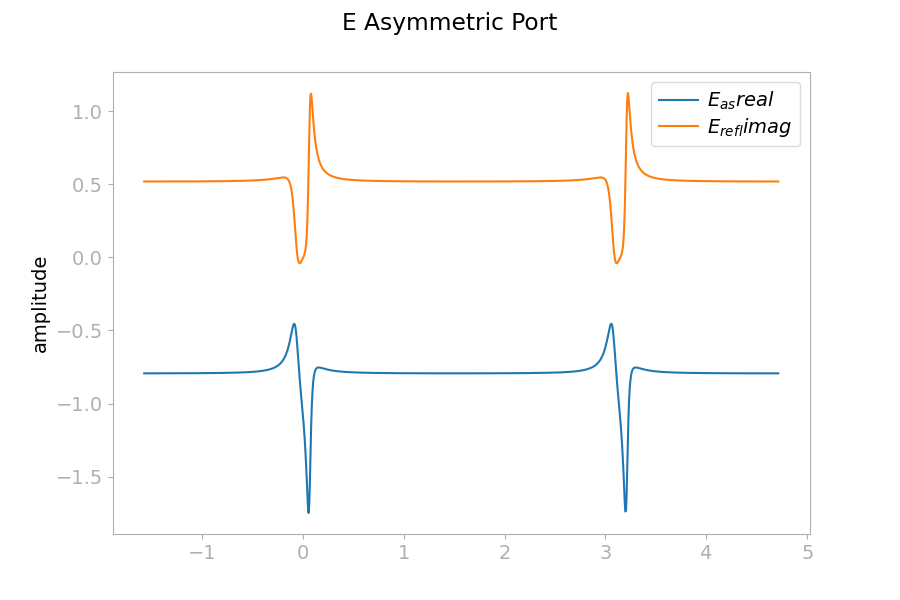

In [40]:

T=np.sqrt(0.1)
R=np.sqrt(0.9)

Eas_simpler =inverted[9,0].subs([(lx,5),(ly,5),(rbs,1/np.sqrt(2)),(tbs,1/np.sqrt(2)),(Lx,Phid+Phic),(Ly,Phid-Phic),(rx,R),(rxe,1),(rye,1),(ry,R),(ty,T),(tx,T),(k,1)]).subs(Phic,8000)

out='$$ E_{as} = '+latex(Eas_simpler)+'$$'
Latex(out)

func = lambdify(Phid, Eas_simpler, 'numpy')
phi_range = np.linspace(-np.pi/2, 3*np.pi/2,1000)



fig,axes=plt.subplots(1)


plt.suptitle('E Asymmetric Port')
axes.plot(phi_range,np.real(func(phi_range)),label = r'$E_{as} real$')
axes.plot(phi_range,np.imag(func(phi_range)),label = r'$E_{refl} imag$')

axes.set_ylabel('amplitude')

axes.legend()

plt.show()